In [1]:
!unzip -q "/content/drive/MyDrive/deep/archive.zip" -d "/content/dataset/"

In [34]:
!pip install thop

In [55]:
import numpy as np
import random
import torch
from sklearn.model_selection import train_test_split
np.random.seed(42)

In [4]:

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/dataset/UCI-HAR Dataset/"

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1

In [63]:
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt" for signal in INPUT_SIGNAL_TYPES
]

y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"


X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)


y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)


In [64]:
# validation 데이터 생성
def load_subject(filepath):
    with open(filepath, "r") as f:
        return np.array([int(x.strip()) for x in f])

subject_train = load_subject(DATASET_PATH + TRAIN + "subject_train.txt")
print("subject_train shape:",  subject_train.shape)

subjects = np.unique(subject_train)
val_subjects = np.random.choice( subjects, size=4, replace=False )

print("val_subject: ", val_subjects)

val_mask = np.isin(subject_train, val_subjects)
train_mask = ~val_mask

X_val = X_train[val_mask]
y_val = y_train[val_mask]
X_train = X_train[train_mask]
y_train = y_train[train_mask]


subject_val = subject_train[val_mask]
subject_train = subject_train[train_mask]
print("Train subjects :", np.unique(subject_train))
print("Val subjects   :", np.unique(subject_val))


subject_train shape: (7352,)
val_subject:  [26  8 17 14]
Train subjects : [ 1  3  5  6  7 11 15 16 19 21 22 23 25 27 28 29 30]
Val subjects   : [ 8 14 17 26]


In [42]:
# GPU 사용 가능 여부 확인 for pytorch
device_available = torch.cuda.is_available()
print(f"GPU 사용 가능 여부: {device_available}")

if device_available:
    device_name = torch.cuda.get_device_name(0)
    print(f"사용 중인 GPU 장치: {device_name}")

    device = torch.device("cuda")
    x = torch.tensor([1.0, 2.0]).to(device)
    print(f"텐서가 할당된 장치: {x.device}")
else:
    print("GPU를 인식하지 못했습니다. 설정을 다시 확인해주세요.")
    model = "cpu"

GPU 사용 가능 여부: True
사용 중인 GPU 장치: Tesla T4
텐서가 할당된 장치: cuda:0


In [66]:
import time
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from thop import profile
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

In [67]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (B, 9, 128)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [68]:
train_dataset = HAR_Dataset(X_train, y_train)
val_dataset = HAR_Dataset(X_val, y_val)
test_dataset  = HAR_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

X_raw shape = (2947, 1152)


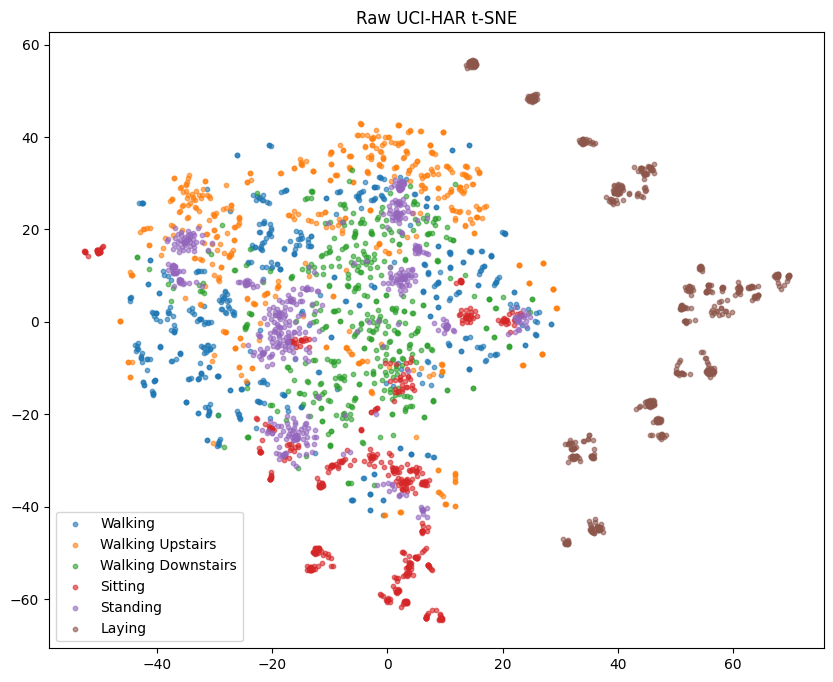

In [69]:
X_raw = X_test.reshape(X_test.shape[0], -1)

print(f"X_raw shape = {X_raw.shape}")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embedding = tsne.fit_transform(X_raw)

activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(10,8))

for i in range(6):
    idx = y_test == i

    plt.scatter(
        embedding[idx,0],
        embedding[idx,1],
        s=10,
        alpha=0.6,
        label=activity_names[i]
    )

plt.legend()
plt.title("Raw UCI-HAR t-SNE")
plt.show()

# **SENet의 SE Block을 구현해보자**

Squeeze랑 Excitation만 하면 되지 뭐... \
더 정확히?
1. GAP로 Squeeze
2. FC 레이어(이 때 크기를 줄임)
3. ReLU
4. FC 레이어(이 때 크기를 복구)
5. sigmoid로 가중치 형태로 만들기
6. element-wise multiple로 가중치 부여

Inception에 붙여보기

In [70]:
class SEBlock(nn.Module):
  def __init__(self, in_channels, r=4):
    super().__init__()

    reduced_channels = max(1, in_channels // r)
    self.squeeze = nn.AdaptiveAvgPool1d(1)

    self.excitation = nn.Sequential(
        nn.Conv1d(in_channels, reduced_channels, kernel_size=1, padding=0),
        nn.ReLU(),
        nn.Conv1d(reduced_channels, in_channels, kernel_size=1, padding=0),
        nn.Sigmoid()
    )


  def forward(self, x):
    squeezed = self.squeeze(x)
    weights = self.excitation(squeezed)

    return x * weights




In [71]:
class InceptionBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    mid_channels = out_channels // 4

    self.branch1 = nn.Sequential(
      nn.Conv1d(in_channels, mid_channels, kernel_size=1),
      nn.BatchNorm1d(mid_channels),
      nn.ReLU()
    )

    self.branch2 = nn.Sequential(
      nn.Conv1d(in_channels, mid_channels, kernel_size=3, padding=1),
      nn.BatchNorm1d(mid_channels),
      nn.ReLU()
    )

    self.branch3 = nn.Sequential(
      nn.Conv1d(in_channels, mid_channels, kernel_size=5, padding=2),
      nn.BatchNorm1d(mid_channels),
      nn.ReLU()
    )

    self.branch4 = nn.Sequential(
      nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
      nn.Conv1d(in_channels, mid_channels, kernel_size=1),
      nn.BatchNorm1d(mid_channels),
      nn.ReLU()
    )

    total_mid_channels = mid_channels * 4

    self.proj = nn.Sequential(
      nn.Conv1d(total_mid_channels, out_channels, kernel_size=1),
      nn.BatchNorm1d(out_channels)
    )
    self.se = SEBlock(out_channels, r=4)



  def forward(self, x):
    f1 = self.branch1(x)
    f2 = self.branch2(x)
    f3 = self.branch3(x)
    f4 = self.branch4(x)

    out = torch.cat([f1, f2, f3, f4], dim=1)
    out = self.proj(out)
    out = self.se(out)
    return F.relu(out)

In [72]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.prep = nn.Sequential(
            nn.Conv1d(9, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.inception1 = InceptionBlock(64, 64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.inception2 = InceptionBlock(64, 128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.inception3 = InceptionBlock(128, 128)

        self.dropout = nn.Dropout(0.4)
        self.fc = nn.LazyLinear(6)

    def forward(self, x, return_feature=False):

        x = self.prep(x)

        x = self.inception1(x)
        x = self.pool1(x)
        x = self.inception2(x)
        x = self.pool2(x)
        x = self.inception3(x)

        x = F.adaptive_avg_pool1d(x, 1)
        feat = torch.flatten(x, 1)
        x = self.dropout(feat)
        logits = self.fc(x)

        if return_feature:
            return logits, feat

        return logits

In [73]:
def train(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    y_pred, y_true = evaluate(model, val_loader)
    val_acc = accuracy_score(y_true, y_pred)

    return epoch_loss, epoch_acc, val_acc

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds)
            all_labels.append(y)

    return (torch.cat(all_preds).cpu(), torch.cat(all_labels).cpu())

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_profile(model):
  dummy_input = torch.randn(1, 9, 128).to(device)
  flops, params = profile(model, inputs=(dummy_input,))
  return flops, params

def benchmark(model, loader):
  model.eval()
  torch.cuda.synchronize()

  start = time.time()
  with torch.no_grad():
    for x, _ in loader:
      x = x.to(device)
      _ = model(x)

  torch.cuda.synchronize()
  end = time.time()

  return end - start

def extract_features(model, loader):
    model.eval()

    features = []
    labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            _, feat = model(X, return_feature=True)

            features.append(feat.cpu().numpy())
            labels.append(y.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels

In [74]:
model = MyModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    loss, acc, val_acc = train(model, train_loader)

    print(f"Epoch {epoch+1}: loss={loss:.4f} | accuracy={acc:.4f} | val_accuracy={val_acc:.4f}")

Epoch 1: loss=0.4642 | accuracy=0.8794 | val_accuracy=0.9047
Epoch 2: loss=0.1537 | accuracy=0.9421 | val_accuracy=0.9010
Epoch 3: loss=0.1395 | accuracy=0.9417 | val_accuracy=0.8248
Epoch 4: loss=0.1186 | accuracy=0.9529 | val_accuracy=0.8666
Epoch 5: loss=0.1233 | accuracy=0.9489 | val_accuracy=0.9304
Epoch 6: loss=0.1153 | accuracy=0.9534 | val_accuracy=0.8974
Epoch 7: loss=0.1135 | accuracy=0.9531 | val_accuracy=0.9003
Epoch 8: loss=0.1150 | accuracy=0.9497 | val_accuracy=0.8783
Epoch 9: loss=0.1146 | accuracy=0.9524 | val_accuracy=0.8710
Epoch 10: loss=0.1113 | accuracy=0.9522 | val_accuracy=0.8915
Epoch 11: loss=0.1072 | accuracy=0.9511 | val_accuracy=0.9157
Epoch 12: loss=0.1036 | accuracy=0.9551 | val_accuracy=0.8930
Epoch 13: loss=0.1120 | accuracy=0.9526 | val_accuracy=0.9260
Epoch 14: loss=0.0989 | accuracy=0.9569 | val_accuracy=0.8988
Epoch 15: loss=0.0936 | accuracy=0.9594 | val_accuracy=0.9135
Epoch 16: loss=0.0892 | accuracy=0.9621 | val_accuracy=0.8908
Epoch 17: loss=0.

In [75]:
y_pred, y_true = evaluate(model, test_loader)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"accuracy = {acc}\nprecision = {prec}\nrecall = {rec}\nf1-score = {f1}")

accuracy = 0.9535120461486257
precision = 0.9577358400816974
recall = 0.953079391555109
f1-score = 0.9532837186340011


In [76]:
model_profile = get_profile(model)
latency = benchmark(model, test_loader)

data = {
    "Model": ["CNN1D"],
    "Params (K)": int(model_profile[1]),
    "FLOPs (M)": model_profile[0],
    "Latency (ms)": latency,
}

df = pd.DataFrame(data)
df

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool1d'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.


,Model,Params (K),FLOPs (M),Latency (ms)
0,CNN1D,131990,6487104.0,0.222078


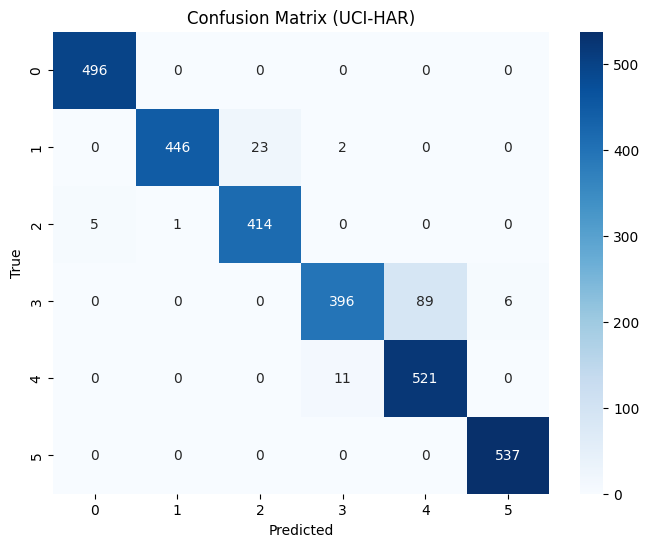

In [77]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (UCI-HAR)")
plt.show()

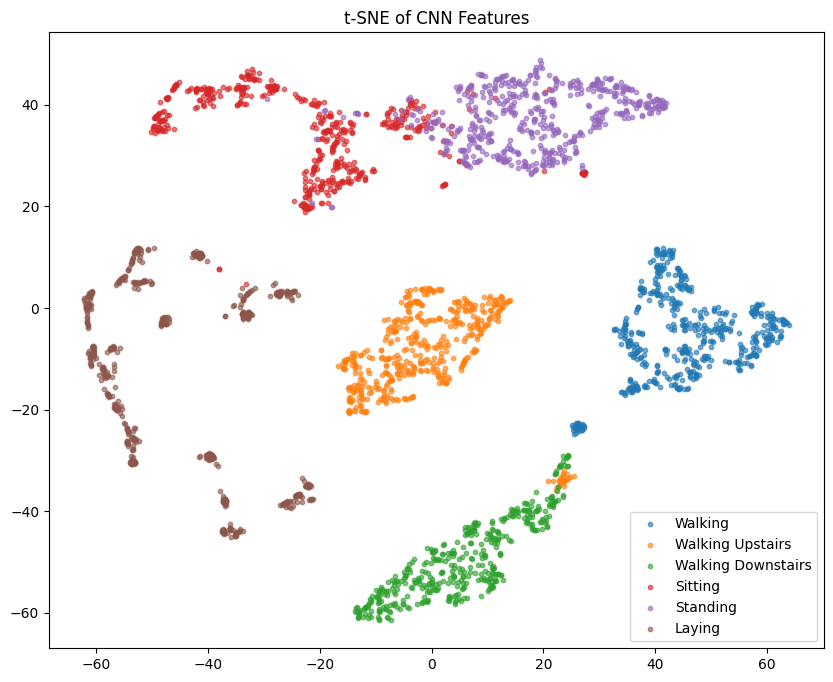

In [78]:
features, labels = extract_features(model, test_loader)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embedding = tsne.fit_transform(features)


activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(10,8))

for i in range(6):
    idx = labels == i

    plt.scatter(
        embedding[idx,0],
        embedding[idx,1],
        label=activity_names[i],
        alpha=0.6,
        s=10
    )

plt.legend()
plt.title("t-SNE of CNN Features")
plt.show()